# Plugging a Custom Algorithm into causal-ts

causal-ts is designed so that any causal discovery algorithm can be registered in three steps:

1. **Subclass `CausalResult`** — set `cg_tig`, `var_names`, `_df`, `_scm_cache`.
2. **Decorate with `@register_algorithm("name")`** — makes the algorithm available to
   `list_algorithms()` and the `causal-ts discover --algorithm name` CLI.
3. **Return your result object** — you automatically inherit `.plot()`, `.estimate_effect()`,
   `.fit_scm()`, `.counterfactual()`, `.attribute_anomaly()`, and all other DoWhy methods.

This notebook walks through a complete worked example: a **Granger causality** algorithm
wrapped using this interface.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from causalts import register_algorithm, list_algorithms, CausalResult
from causalts.utils import evaluate_graph
from causalts.synthetic_data.synthetic_datasets import load_dataset
import causalts.plotting as tp

# Datasets used throughout
data_ex2 = load_dataset('ex2', seed=42, T=300)
df_ex2, gt_ex2 = data_ex2['df'], data_ex2['ground_truth']

print("Before registration:", list_algorithms())

Before registration: ['cdnots', 'cdnots+', 'grace', 'grace-ss', 'cedar']


## Step 1 — Define a Result class

Subclass `CausalResult` and set the four required attributes.
Everything else — plotting, DoWhy, CLI saving — is inherited.

In [2]:
class GrangerResult(CausalResult):
    """Result from Naive Granger discovery."""

    def __init__(self, graph, var_names, df, *, aic=None, max_lag_fit=None):
        self.cg_tig     = graph               # (d, d, max_lag+1) — REQUIRED
        self.var_names  = list(var_names)     # list[str]         — REQUIRED
        self._df        = df                  # pd.DataFrame      — REQUIRED
        self._scm_cache = {}                  # empty dict        — REQUIRED
        # algorithm-specific extras (optional)
        self.aic         = aic
        self.max_lag_fit = max_lag_fit

    def __repr__(self):
        d = len(self.var_names)
        edges = int((self.cg_tig == 1).sum())
        return (f"GrangerResult(vars={d}, edges={edges}, "
                f"max_lag_fit={self.max_lag_fit}, aic={self.aic:.1f})"
                if self.aic else f"GrangerResult(vars={d}, edges={edges})")


## Step 2 — Implement and register the algorithm

The function signature must accept `df`, `ci_test`, and `max_lag` as positional
arguments (so the registry can call it uniformly). Extra parameters go in `**kwargs`
or as keyword-only args.

In [3]:
@register_algorithm("granger")
def run_granger(df, ci_test=None, max_lag=3, *, alpha=0.05, **kwargs):
    """Naive Granger causality via OLS VAR regression.

    Fits a VAR(max_lag) model with statsmodels and keeps edges where the
    coefficient p-value is below *alpha*. This is a deliberately simple
    algorithm — the point is to show the integration, not the statistics.

    Parameters
    ----------
    df : pd.DataFrame
    ci_test : ignored — Granger uses OLS internally
    max_lag : int
    alpha : float
        P-value threshold for coefficient significance.
    """
    from statsmodels.tsa.api import VAR

    d = df.shape[1]
    mdl   = VAR(df.values).fit(maxlags=max_lag, trend='n')
    n_fit = mdl.k_ar                               # lags actually fitted

    graph = np.zeros((d, d, max_lag + 1), dtype=np.int8)
    for lag in range(1, min(n_fit, max_lag) + 1):
        # pvalues block for this lag: rows = causes, cols = effects (statsmodels convention)
        block = mdl.pvalues[(lag - 1) * d : lag * d, :]   # (d_causes, d_effects)
        for cause in range(d):
            for effect in range(d):
                if cause != effect and block[cause, effect] <= alpha:
                    graph[cause, effect, lag] = 1

    return GrangerResult(
        graph=graph,
        var_names=list(df.columns),
        df=df,
        aic=mdl.aic,
        max_lag_fit=n_fit,
    )

print("After registration:", list_algorithms())

After registration: ['cdnots', 'cdnots+', 'grace', 'grace-ss', 'granger', 'cedar']


## Step 3 — Run and evaluate

In [4]:
res = run_granger(df_ex2, max_lag=3, alpha=0.05)
print(res)

m = evaluate_graph(res.cg_tig, gt_ex2)
print(f"F1={m['F1']:.3f}  Precision={m['Precision']:.3f}  Recall={m['TPR']:.3f}  SHD={m['SHD']}")

GrangerResult(vars=6, edges=15, max_lag_fit=3, aic=0.3)
F1=0.538  Precision=0.467  Recall=0.636  SHD=12


## Step 4 — Plotting and comparison (inherited for free)

Because `GrangerResult` subclasses `CausalResult`, `.plot()` and `compare_graphs()`
work without any extra code.

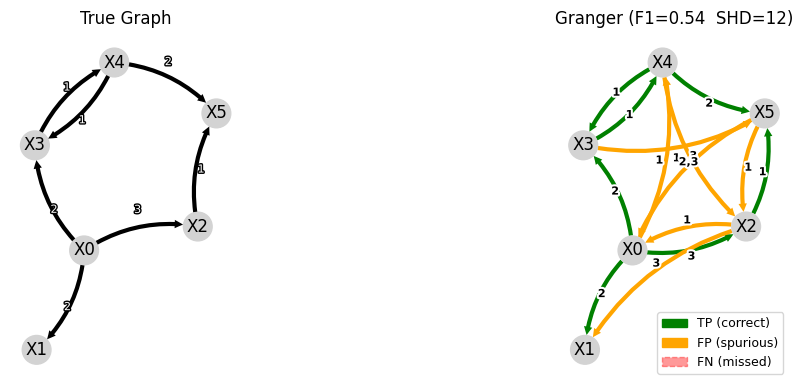

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

_, _, pos = tp.plot_graph(
    gt_ex2, var_names=list(df_ex2.columns),
    arrow_linewidth=3, link_label_fontsize=8, node_size=0.2,
    show_colorbar=False, fig_ax=(fig, axes[0]), return_pos=True,
)
axes[0].set_title("True Graph", fontsize=12)

tp.compare_graphs(
    gt_ex2, res.cg_tig,
    var_names=list(df_ex2.columns), node_pos=pos,
    arrow_linewidth=3, link_label_fontsize=8, node_size=0.2,
    fig_ax=(fig, axes[1]), legend_loc=None,
)
axes[1].set_title(
    f"Granger (F1={m['F1']:.2f}  SHD={m['SHD']})", fontsize=12
)
plt.tight_layout()
plt.show()

## Step 5 — DoWhy bridge (inherited for free)

Effect estimation, counterfactuals, and root cause analysis work on any
`CausalResult` subclass. Install DoWhy with `pip install causalts[dowhy]`.

In [7]:
try:
    effect = res.estimate_effect(
        treatment='X3', outcome='X4', treatment_lag=1,
        method='backdoor.linear_regression',
        confidence_intervals=False,
    )
    print(f"ATE  X3(t-1) → X4 : {effect.value:+.4f}")
except ImportError:
    print("DoWhy not installed. Run:  pip install 'causalts[dowhy]'")

ATE  X3(t-1) → X4 : -0.7435


## Step 6 — CLI integration

Once your module is imported, the CLI picks up your algorithm automatically.
No edits to causal-ts source code are required.

```python
# my_granger_plugin.py
from causalts import register_algorithm, CausalResult
...
@register_algorithm("granger")
def run_granger(...): ...
```

```bash
# In your shell session after importing your module:
causal-ts discover data.csv --algorithm granger --max-lag 3
```

Or from Python:

```python
from causalts.algorithms import run_algorithm
import my_granger_plugin  # triggers registration

res = run_algorithm("granger", df=df, ci_test=None, max_lag=3)
```

## Summary — Minimal interface checklist

To integrate any causal discovery algorithm:

```python
from causalts import register_algorithm, CausalResult
import numpy as np

class MyResult(CausalResult):
    def __init__(self, graph, df, var_names):
        self.cg_tig     = graph           # np.ndarray (d, d, max_lag+1), dtype int8
        self.var_names  = list(var_names) # list[str]
        self._df        = df              # pd.DataFrame — needed for DoWhy bridge
        self._scm_cache = {}              # empty dict

@register_algorithm("my_algo")
def run_my_algo(df, ci_test, max_lag, **kwargs):
    d = df.shape[1]
    graph = np.zeros((d, d, max_lag + 1), dtype=np.int8)
    # ... your discovery logic ...
    return MyResult(graph, df, list(df.columns))
```

**Inherited for free:**
- `result.plot(**kwargs)` — network graph visualization
- `result.estimate_effect(treatment, outcome, ...)` — DoWhy ATE
- `result.fit_scm()` / `result.counterfactual(...)` — structural causal model
- `result.attribute_anomaly(...)` — Shapley root cause attribution
- `causal-ts discover --algorithm my_algo data.csv` — CLI

**Optional overrides:**
- `__repr__` — custom summary string
- `plot()` — custom plot defaults (e.g., `show_colorbar=False`)
- `_bridge()` — custom DoWhy graph preparation (see `CedarResult` for an example
  that restores implicit AR(1) self-lags before DoWhy sees the graph)